[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dongzoolee/hidden-bites/blob/main/notebooks/review-expression-analysis.ipynb)

# 네이버 지도 리뷰 표현 분석

이 노트북은 `datasets/naver-map-reviews-2026-05-13.json`에 들어 있는 네이버 지도 리뷰 500개를 바탕으로, 유저들이 실제로 사용한 표현을 추출하고 비슷한 의미의 표현끼리 묶어 봅니다.

수업에서 배운 Word2Vec은 한 단어가 주변 단어와 함께 나타나는 패턴을 이용해 의미를 벡터로 배웁니다. 이 프로젝트의 corpus는 아직 500개 리뷰로 작기 때문에 Word2Vec을 처음부터 학습하면 안정적인 임베딩을 얻기 어렵습니다. 대신 같은 아이디어를 더 작은 데이터에 맞게 바꿉니다. 여기서는 표현이 어떤 리뷰, 장소, 카테고리, 네이버 키워드, 방문 맥락과 함께 등장했는지를 co-occurrence vector로 만들고, cosine similarity로 가까운 표현들을 묶습니다.

목표는 두 가지입니다. 첫째, `맛있어요`, `친절해요`, `분위기`처럼 여러 리뷰에 넓게 퍼진 dense한 표현군을 찾습니다. 둘째, 빈도는 낮지만 특정 장소를 잘 설명하는 sparse한 표현을 찾아 Hidden Bites의 장소별 signature로 사용할 수 있게 합니다.

## 0. 실행 환경 준비

Colab에서 바로 실행할 수 있도록 필요한 패키지를 설치합니다. 로컬에서 이미 설치되어 있다면 이 셀은 빠르게 지나갑니다. `kiwipiepy`는 한국어 형태소 분석을 위해 사용하고, `scikit-learn`은 co-occurrence vector와 cosine similarity 계산에 사용합니다. `koreanize-matplotlib`은 차트의 한글 라벨이 깨지지 않도록 사용합니다.

In [87]:
%pip install -q pandas numpy scikit-learn matplotlib networkx kiwipiepy koreanize-matplotlib

## 1. 데이터 로드와 flat table 구성

원본 JSON은 장소별로 리뷰가 중첩된 구조입니다. 분석하기 쉽도록 리뷰 한 개가 한 행이 되도록 펼칩니다. 원문 리뷰, 네이버 키워드, 장소명, 카테고리, 방문 목적, 동행 형태, 대기 시간 정보를 모두 보존합니다.

In [88]:
import json
import re
from collections import Counter
from urllib.request import urlopen

try:
    import koreanize_matplotlib
except ModuleNotFoundError:
    pass

import matplotlib.pyplot as plt
from matplotlib import font_manager
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display
from kiwipiepy import Kiwi
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics.pairwise import cosine_similarity

dataset_url = "https://raw.githubusercontent.com/dongzoolee/hidden-bites/refs/heads/main/datasets/naver-map-reviews-2026-05-13.json"

with urlopen(dataset_url) as response:
    data = json.loads(response.read().decode("utf-8"))

rows = []

for location_item in data["locations"]:
    location = location_item["location"]
    for review in location_item["reviews"]:
        rows.append(
            {
                "review_id": f"{location_item['position']:02d}-{review['rank']:02d}",
                "location_name": location["name"],
                "location_type": location["type"],
                "category": location.get("category"),
                "rank": review["rank"],
                "visited_date": review.get("visited_date"),
                "visit_time_label": review.get("visit_time_label"),
                "reserved": review.get("reserved"),
                "waiting_label": (review.get("waiting") or {}).get("label"),
                "purpose": review.get("purpose") or [],
                "companion": review.get("companion"),
                "text": review.get("text") or "",
                "naver_keywords": review.get("naver_keywords") or [],
            }
        )

reviews_df = pd.DataFrame(rows)
summary_df = pd.DataFrame(
    [
        {"metric": "locations", "value": data["locations_count"]},
        {"metric": "reviews", "value": data["reviews_count"]},
        {"metric": "non_empty_text_reviews", "value": int(reviews_df["text"].str.strip().ne("").sum())},
    ]
)

display(summary_df)
display(reviews_df.head())

,metric,value
0,locations,10
1,reviews,4091
2,non_empty_text_reviews,3961


,review_id,location_name,location_type,category,rank,visited_date,visit_time_label,reserved,waiting_label,purpose,companion,text,naver_keywords
0,01-01,탕화쿵푸마라탕 압구정역점,restaurant,마라탕,1,2026-05-12,None,no,바로 입장,"[travel, daily]",alone,믿고먹는 탕화쿵푸!! 역시 맛있는데 매장도 청결하고 재료도 잘관리돼는거같아요 맛있게...,"[음식이 맛있어요, 재료가 신선해요, 양이 많아요, 가성비가 좋아요, 혼밥하기 좋아요]"
1,01-02,탕화쿵푸마라탕 압구정역점,restaurant,마라탕,2,2026-05-12,None,no,바로 입장,[daily],alone,오늘도 맛있게 먹고 갑니다!,"[인테리어가 멋져요, 매장이 넓어요, 혼밥하기 좋아요, 양이 많아요, 음식이 맛있어요]"
2,01-03,탕화쿵푸마라탕 압구정역점,restaurant,마라탕,3,2026-05-12,None,no,바로 입장,[daily],alone,저번에 왔을때도 맛있게 먹어서 또 왔습니다,"[음식이 맛있어요, 재료가 신선해요, 혼밥하기 좋아요]"
3,01-04,탕화쿵푸마라탕 압구정역점,restaurant,마라탕,4,2026-05-12,None,no,바로 입장,"[friends, business, daily]",friends,오늘은 마라상궈와 꿔바로우를 먹었는데 역시 맛있네요,"[음식이 맛있어요, 친절해요, 샐러드바가 잘 되어있어요]"
4,01-05,탕화쿵푸마라탕 압구정역점,restaurant,마라탕,5,2026-05-10,None,no,바로 입장,"[family, daily]",family,진찌진찌진짜맛있어요,[음식이 맛있어요]


## 2. 분석 기준 설정

여기서 정하는 threshold는 이번 노트북의 해석 규칙입니다. 리뷰 수가 늘어나면 기준도 다시 조정할 수 있습니다.

- `dense`는 여러 리뷰와 여러 장소에서 반복되고, 주변에 유사 표현도 있는 표현입니다.
- `sparse_meaningful`은 빈도는 낮지만 특정 장소에 강하게 몰린 표현입니다.
- `sparse_noise`는 한 번만 등장하고 의미 연결도 약한 표현입니다.

Word2Vec에서 주변 단어 window를 쓰듯이, 이 노트북은 리뷰 하나를 작은 context window로 봅니다. 같은 리뷰 안에서 함께 등장한 키워드, 장소, 카테고리, 방문 맥락이 표현의 의미를 설명하는 feature가 됩니다.

In [89]:
MIN_TOKEN_LENGTH = 2
MIN_DENSE_REVIEW_COUNT = 8
MIN_DENSE_LOCATION_COUNT = 3
MIN_DENSE_NEIGHBORS = 2
SPARSE_MAX_REVIEW_COUNT = 2
SPARSE_LIFT_THRESHOLD = 2.0
SIMILARITY_THRESHOLD = 0.90
MAX_EXPRESSIONS_FOR_GRAPH = 220
MAX_NETWORK_NODES = 80

ALLOWED_TAG_PREFIXES = ("N", "V", "XR", "SL", "SN")

STOPWORDS = {
    "하다",
    "되다",
    "이다",
    "아니다",
    "있다",
    "없다",
    "같다",
    "오다",
    "가다",
    "먹다",
    "보다",
    "싶다",
    "주다",
    "않다",
    "나다",
    "알다",
    "시키다",
    "들다",
    "정도",
    "오늘",
    "이번",
    "저번",
    "방문",
    "이용",
    "매장",
    "곳",
    "때",
    "것",
    "수",
    "듯",
    "진짜",
    "너무",
    "정말",
    "항상",
    "자주",
    "다시",
    "처음",
    "완전",
    "그리고",
    "근데",
    "여기",
    "저희",
    "제가",
}

def resolve_korean_font_family():
    candidate_names = ["NanumGothic", "AppleGothic", "Malgun Gothic", "Noto Sans CJK KR", "Noto Sans KR"]
    available_names = {font.name for font in font_manager.fontManager.ttflist}
    for name in candidate_names:
        if name in available_names:
            return name
    current_family = plt.rcParams.get("font.family", ["sans-serif"])
    if isinstance(current_family, str):
        return current_family
    return current_family[0] if current_family else "sans-serif"


KOREAN_FONT_FAMILY = resolve_korean_font_family()
kiwi = Kiwi()
plt.rcParams["font.family"] = KOREAN_FONT_FAMILY
plt.rcParams["axes.unicode_minus"] = False

## 3. 표현 후보 추출

네이버 키워드는 이미 리뷰 플랫폼이 제공하는 의미 단위이므로 anchor expression으로 그대로 사용합니다. 리뷰 원문에서는 Kiwi 형태소 분석으로 명사, 동사, 형용사, 어근 중심의 normalized token을 뽑습니다.

예를 들어 `맛있고`, `맛있어요`, `맛있습니다`처럼 표면형은 다르지만 의미가 가까운 표현은 `맛있다` 같은 정규화된 token으로 모이게 됩니다. 반대로 원문 전체 문장은 대표 예시로 남겨 나중에 해석할 때 실제 표현을 다시 볼 수 있게 합니다.

In [90]:
def normalize_text_token(token):
    form = token.form.strip().lower()
    tag = token.tag
    if not form:
        return None
    if not tag.startswith(ALLOWED_TAG_PREFIXES):
        return None
    if tag.startswith("V") and not form.endswith("다"):
        form = f"{form}다"
    if len(form) < MIN_TOKEN_LENGTH:
        return None
    if form in STOPWORDS:
        return None
    if re.fullmatch(r"[0-9]+", form):
        return None
    return form


def normalize_keyword(keyword):
    expression = re.sub(r"\s+", " ", str(keyword).strip())
    if len(expression) < MIN_TOKEN_LENGTH:
        return None
    return expression


def extract_text_expressions(text):
    expressions = []
    for token in kiwi.tokenize(text):
        normalized = normalize_text_token(token)
        if normalized is not None:
            expressions.append(normalized)
    return expressions


expression_rows = []

for row in reviews_df.itertuples(index=False):
    text_expressions = extract_text_expressions(row.text)
    for expression in text_expressions:
        expression_rows.append(
            {
                "review_id": row.review_id,
                "expression": expression,
                "source": "text_token",
            }
        )
    for keyword in row.naver_keywords:
        expression = normalize_keyword(keyword)
        if expression is not None:
            expression_rows.append(
                {
                    "review_id": row.review_id,
                    "expression": expression,
                    "source": "naver_keyword",
                }
            )

expressions_df = pd.DataFrame(expression_rows).drop_duplicates()
expression_review_df = expressions_df.drop_duplicates(["review_id", "expression"])
expression_context_df = expression_review_df.merge(reviews_df, on="review_id", how="left")

source_types_df = (
    expressions_df.groupby("expression")["source"]
    .apply(lambda values: ", ".join(sorted(set(values))))
    .reset_index(name="source_types")
)

example_text_df = (
    expression_context_df[expression_context_df["text"].str.strip().ne("")]
    .groupby("expression")["text"]
    .first()
    .reset_index(name="example_text")
)

expression_stats = (
    expression_context_df.groupby("expression")
    .agg(
        review_count=("review_id", "nunique"),
        location_count=("location_name", "nunique"),
        category_count=("category", "nunique"),
    )
    .reset_index()
    .merge(source_types_df, on="expression", how="left")
    .merge(example_text_df, on="expression", how="left")
    .sort_values(["review_count", "location_count", "expression"], ascending=[False, False, True])
    .reset_index(drop=True)
)

display(expression_stats.head(30))
print(f"표현 후보 수: {len(expression_stats):,}")

,expression,review_count,location_count,category_count,source_types,example_text
0,음식이 맛있어요,2310,10,9,naver_keyword,믿고먹는 탕화쿵푸!! 역시 맛있는데 매장도 청결하고 재료도 잘관리돼는거같아요 맛있게...
1,맛있다,2196,10,9,text_token,믿고먹는 탕화쿵푸!! 역시 맛있는데 매장도 청결하고 재료도 잘관리돼는거같아요 맛있게...
2,재료가 신선해요,1433,10,9,naver_keyword,믿고먹는 탕화쿵푸!! 역시 맛있는데 매장도 청결하고 재료도 잘관리돼는거같아요 맛있게...
3,좋다,1366,10,9,text_token,항상 잘 애용하고 있어요. 친절하게 아이 입맛에도 맛게 조리해주시고 아이가 좋아해요.
4,친절해요,1078,10,9,naver_keyword,오늘은 마라상궈와 꿔바로우를 먹었는데 역시 맛있네요
5,인테리어가 멋져요,1042,10,9,naver_keyword,오늘도 맛있게 먹고 갑니다!
6,빵이 맛있어요,962,3,3,naver_keyword,이렇게 유명하기 전부터 좋아하던 베이글집이에요 베이글은 식감이라고 생각했는데 여기는...
7,특별한 메뉴가 있어요,892,10,9,naver_keyword,마라탕 국물 진하고 얼얼한 맛이 딱 좋았어요! 재료도 신선하고 원하는 재료 골라 먹...
8,커피가 맛있어요,628,4,4,naver_keyword,주말 아침 최고의 선택입니다.
9,가성비가 좋아요,543,10,9,naver_keyword,믿고먹는 탕화쿵푸!! 역시 맛있는데 매장도 청결하고 재료도 잘관리돼는거같아요 맛있게...


표현 후보 수: 3,313


## 4. Co-occurrence vector 만들기

각 표현을 숫자 벡터로 만들기 위해, 표현이 등장한 리뷰의 주변 정보를 feature로 모읍니다. 이 방식은 작은 데이터셋에서 Word2Vec을 직접 학습하는 대신, Word2Vec의 핵심 직관인 `같은 맥락에 등장하는 표현은 의미가 가깝다`를 직접 구현한 것입니다.

예를 들어 `혼밥하기 좋아요`와 `혼자`가 같은 리뷰, 같은 장소, 같은 키워드와 자주 연결되면 두 표현의 vector가 가까워집니다. `빵이 맛있어요`와 `베이글`도 베이커리/카페 리뷰 맥락에서 가까워질 수 있습니다.

In [91]:
candidate_expressions = expression_stats[
    (expression_stats["review_count"] >= 2)
    | expression_stats["source_types"].str.contains("naver_keyword", regex=False)
].head(MAX_EXPRESSIONS_FOR_GRAPH)["expression"].tolist()

candidate_context_df = expression_context_df[expression_context_df["expression"].isin(candidate_expressions)]

feature_rows = []
feature_expressions = []

for expression, group in candidate_context_df.groupby("expression"):
    features = Counter()
    for row in group.itertuples(index=False):
        features[f"review:{row.review_id}"] += 1.0
        features[f"location:{row.location_name}"] += 1.8
        features[f"category:{row.category}"] += 1.2
        features[f"visit_time:{row.visit_time_label}"] += 0.7
        features[f"companion:{row.companion}"] += 0.7
        features[f"waiting:{row.waiting_label}"] += 0.7
        for purpose in row.purpose:
            features[f"purpose:{purpose}"] += 0.7
        for keyword in row.naver_keywords:
            features[f"keyword:{keyword}"] += 1.4
    feature_expressions.append(expression)
    feature_rows.append(dict(features))

vectorizer = DictVectorizer(sparse=True)
context_matrix = vectorizer.fit_transform(feature_rows)
similarity_matrix = cosine_similarity(context_matrix)

G = nx.Graph()
G.add_nodes_from(feature_expressions)

for left_index in range(len(feature_expressions)):
    for right_index in range(left_index + 1, len(feature_expressions)):
        similarity = float(similarity_matrix[left_index, right_index])
        if similarity >= SIMILARITY_THRESHOLD:
            G.add_edge(feature_expressions[left_index], feature_expressions[right_index], weight=similarity)

neighbor_counts = dict(G.degree())

cluster_rows = []
cluster_map = {}

components = sorted(nx.connected_components(G), key=lambda component: (-len(component), sorted(component)[0]))
for cluster_id, component in enumerate(components, start=1):
    component_stats = expression_stats[expression_stats["expression"].isin(component)].copy()
    representative = component_stats.sort_values(["review_count", "location_count", "expression"], ascending=[False, False, True]).iloc[0]
    component_context = expression_context_df[expression_context_df["expression"].isin(component)]
    locations = sorted(component_context["location_name"].dropna().unique().tolist())[:5]
    examples = component_context[component_context["text"].str.strip().ne("")]["text"].drop_duplicates().head(3).tolist()
    for expression in component:
        cluster_map[expression] = cluster_id
    if len(component) >= 2:
        cluster_rows.append(
            {
                "cluster_id": cluster_id,
                "representative": representative["expression"],
                "expression_count": len(component),
                "total_review_mentions": int(component_stats["review_count"].sum()),
                "expressions": ", ".join(component_stats.head(12)["expression"].tolist()),
                "locations": ", ".join(locations),
                "examples": " / ".join(examples),
            }
        )

cluster_columns = ["cluster_id", "representative", "expression_count", "total_review_mentions", "expressions", "locations", "examples"]
if cluster_rows:
    cluster_df = pd.DataFrame(cluster_rows).sort_values(["expression_count", "total_review_mentions"], ascending=[False, False])
else:
    cluster_df = pd.DataFrame(columns=cluster_columns)

display(cluster_df.head(20))
print(f"분석 표현 수: {len(feature_expressions):,}")
print(f"유사 표현 edge 수: {G.number_of_edges():,}")
print(f"크기 2 이상 cluster 수: {len(cluster_df):,}")

,cluster_id,representative,expression_count,total_review_mentions,expressions,locations,examples
0,1,음식이 맛있어요,186,27736,"음식이 맛있어요, 맛있다, 재료가 신선해요, 좋다, 친절해요, 인테리어가 멋져요, ...","광어연어, 규카츠정 성수점, 대진 도원참치 강남역점, 또바기, 마더린러 베이글",믿고먹는 탕화쿵푸!! 역시 맛있는데 매장도 청결하고 재료도 잘관리돼는거같아요 맛있게...
1,2,피자,6,553,"피자, 화덕, 도우, 마르게리따, 리조또, 풍기","마더린러 베이글, 어반플랜트 합정, 팔로피자",친구랑 양식이 먹고 싶어서 예약 후 이용했습니다. 브레이크 타임 끝난 5시에 바로 ...
2,3,여의도,5,225,"여의도, 빵집, 소금, 케이크, 동네","광어연어, 규카츠정 성수점, 또바기, 마더린러 베이글, 보배반점 양재점",새로 생겨 깔끔하고 맛있어요 동네 초딩들 여기 다 모였네요ㅎㅎ 친절하시고 새 매장이...


분석 표현 수: 220
유사 표현 edge 수: 2,168
크기 2 이상 cluster 수: 3


## 5. Sparse / dense 표현 분리

표현을 단순히 많이 나온 순서로만 보면 `맛있다`, `좋다`처럼 모든 장소에 흔한 말만 보입니다. Hidden Bites에서는 흔한 만족 표현과 특정 장소를 설명하는 희소 표현을 나눠 보는 것이 중요합니다.

그래서 빈도, 장소 확산도, 유사 이웃 수, 특정 장소 집중도 lift를 함께 봅니다. lift는 어떤 표현이 특정 장소에 몰려 있는 정도입니다. 전체 리뷰 중 한 장소가 차지하는 비율보다, 해당 표현의 리뷰가 그 장소에 나타나는 비율이 훨씬 높으면 lift가 큽니다.

In [92]:
total_reviews = reviews_df["review_id"].nunique()
location_base_share = reviews_df.groupby("location_name")["review_id"].nunique() / total_reviews
expression_location_counts = expression_context_df.groupby(["expression", "location_name"])["review_id"].nunique()
expression_review_counts = expression_context_df.groupby("expression")["review_id"].nunique()

max_lift_rows = []

for expression, review_count in expression_review_counts.items():
    location_counts = expression_location_counts.loc[expression]
    lift_values = {}
    for location_name, count in location_counts.items():
        expression_share = count / review_count
        lift_values[location_name] = expression_share / location_base_share.loc[location_name]
    top_location = max(lift_values, key=lift_values.get)
    max_lift_rows.append(
        {
            "expression": expression,
            "top_location": top_location,
            "max_location_lift": float(lift_values[top_location]),
        }
    )

lift_df = pd.DataFrame(max_lift_rows)

analysis_stats = expression_stats.merge(lift_df, on="expression", how="left")
analysis_stats["neighbor_count"] = analysis_stats["expression"].map(neighbor_counts).fillna(0).astype(int)
analysis_stats["cluster_id"] = analysis_stats["expression"].map(cluster_map)

def classify_expression(row):
    has_keyword_anchor = "naver_keyword" in str(row.source_types)
    if (
        row.review_count >= MIN_DENSE_REVIEW_COUNT
        and row.location_count >= MIN_DENSE_LOCATION_COUNT
        and row.neighbor_count >= MIN_DENSE_NEIGHBORS
    ):
        return "dense"
    if (
        row.review_count <= SPARSE_MAX_REVIEW_COUNT
        and row.max_location_lift >= SPARSE_LIFT_THRESHOLD
        and (row.review_count == SPARSE_MAX_REVIEW_COUNT or has_keyword_anchor)
    ):
        return "sparse_meaningful"
    if row.review_count <= 1 and row.neighbor_count == 0:
        return "sparse_noise"
    return "middle"

analysis_stats["density_label"] = analysis_stats.apply(classify_expression, axis=1)

label_summary_df = (
    analysis_stats.groupby("density_label")
    .agg(expressions=("expression", "count"), mean_review_count=("review_count", "mean"), mean_location_count=("location_count", "mean"))
    .reset_index()
    .sort_values("expressions", ascending=False)
)

dense_df = analysis_stats[analysis_stats["density_label"].eq("dense")].sort_values(
    ["review_count", "neighbor_count", "location_count"], ascending=[False, False, False]
)

sparse_meaningful_df = analysis_stats[analysis_stats["density_label"].eq("sparse_meaningful")].sort_values(
    ["max_location_lift", "neighbor_count", "review_count"], ascending=[False, False, False]
)

sparse_noise_df = analysis_stats[analysis_stats["density_label"].eq("sparse_noise")].sort_values(
    ["review_count", "expression"], ascending=[False, True]
)

display(label_summary_df)
display(dense_df.head(25)[["expression", "review_count", "location_count", "neighbor_count", "source_types", "example_text"]])
display(sparse_meaningful_df.head(25)[["expression", "review_count", "top_location", "max_location_lift", "neighbor_count", "example_text"]])

,density_label,expressions,mean_review_count,mean_location_count
3,sparse_noise,1567,1.000000,1.000000
1,middle,1143,15.107612,3.104987
2,sparse_meaningful,441,1.997732,1.512472
0,dense,162,156.759259,7.592593


,expression,review_count,location_count,neighbor_count,source_types,example_text
0,음식이 맛있어요,2310,10,30,naver_keyword,믿고먹는 탕화쿵푸!! 역시 맛있는데 매장도 청결하고 재료도 잘관리돼는거같아요 맛있게...
1,맛있다,2196,10,53,text_token,믿고먹는 탕화쿵푸!! 역시 맛있는데 매장도 청결하고 재료도 잘관리돼는거같아요 맛있게...
2,재료가 신선해요,1433,10,17,naver_keyword,믿고먹는 탕화쿵푸!! 역시 맛있는데 매장도 청결하고 재료도 잘관리돼는거같아요 맛있게...
3,좋다,1366,10,61,text_token,항상 잘 애용하고 있어요. 친절하게 아이 입맛에도 맛게 조리해주시고 아이가 좋아해요.
4,친절해요,1078,10,3,naver_keyword,오늘은 마라상궈와 꿔바로우를 먹었는데 역시 맛있네요
5,인테리어가 멋져요,1042,10,11,naver_keyword,오늘도 맛있게 먹고 갑니다!
6,빵이 맛있어요,962,3,4,naver_keyword,이렇게 유명하기 전부터 좋아하던 베이글집이에요 베이글은 식감이라고 생각했는데 여기는...
8,커피가 맛있어요,628,4,2,naver_keyword,주말 아침 최고의 선택입니다.
10,친절,534,10,45,text_token,아이가 제일 좋아하는 마라탕집이예요. 다른곳도 다녀봤지만 식재료도 깔끔하고 식기류도...
14,분위기,412,10,32,text_token,탕화쿵푸 마라탕 정말 만족스러웠어요. 매장 환경이 깔끔하고 쾌적해서 편하게 식사할 ...


,expression,review_count,top_location,max_location_lift,neighbor_count,example_text
1565,당산,2,또바기,43.063158,0,요즘 보기 드문 당산의 백반 점문점 또바기 대구탕을 먹었구요 시원 칼칼하게 잘 먹고...
1580,또바기,2,또바기,43.063158,0,오늘 점심은 그동안 벼르던 또바기 생선구이...양이 많네요~~🐟🍚👍💯
1620,삼겹살,2,또바기,43.063158,0,혼밥하기도 좋고 함께 가서 먹기도 좋아요. 반찬만으로도 밥 한공기 순삭 가능한 곳!...
1621,삼치,2,또바기,43.063158,0,"또바기 제육, 삼치구이 굿 맛있어요"
1673,제육,2,또바기,43.063158,0,제육 김치찌개 생선구이 먹었습니다 늘 맛있게 요리해주셔서 감사합니다
1675,조미료,2,또바기,43.063158,0,혼밥하기도 좋고 함께 가서 먹기도 좋아요. 반찬만으로도 밥 한공기 순삭 가능한 곳!...
1695,청국장,2,또바기,43.063158,0,음식이 맛있고 넉넉 합니다 여기 대표 메뉴는 청국장. 생선구이 입니다
1728,한정식,2,또바기,43.063158,0,"김치찌개, 생선구이 맛나네요. 밑반찬이 7~8개....한정식 한상 분위기. 가성비 ..."
1335,김치,2,또바기,21.531579,0,혼밥하기도 좋고 함께 가서 먹기도 좋아요. 반찬만으로도 밥 한공기 순삭 가능한 곳!...
1347,단위,2,또바기,21.531579,0,불고기 잡채밥은 처음 먹어보는데 맛있어요! 모든 직원분들이 늘 친절하시고 청결하고 ...


## 6. 장소별 sparse signature 보기

`sparse_meaningful` 표현은 많이 등장하지 않더라도 특정 장소를 설명하는 단서가 될 수 있습니다. 아래 표는 장소별로 lift가 높은 표현을 모아 보여 줍니다.

이 표는 최종 시각화에서 `이 장소가 다른 장소와 다르게 언급되는 지점`을 만드는 데 사용할 수 있습니다.

In [93]:
signature_rows = []

for location_name, group in sparse_meaningful_df.groupby("top_location"):
    top_group = group.head(12)
    signature_rows.append(
        {
            "location_name": location_name,
            "signature_expressions": ", ".join(top_group["expression"].tolist()),
            "mean_lift": float(top_group["max_location_lift"].mean()),
            "expression_count": len(top_group),
        }
    )

signature_columns = ["location_name", "signature_expressions", "mean_lift", "expression_count"]
if signature_rows:
    signature_df = pd.DataFrame(signature_rows).sort_values(["expression_count", "mean_lift"], ascending=[False, False])
else:
    signature_df = pd.DataFrame(columns=signature_columns)

display(signature_df)

,location_name,signature_expressions,mean_lift,expression_count
3,또바기,"당산, 또바기, 삼겹살, 삼치, 제육, 조미료, 청국장, 한정식, 김치, 단위, 드...",35.885965,12
0,광어연어,"감자채샐러드, 감자튀김, 도둑, 멍게, 석화, 신림역, 용기, 이르다, 중자, 횟감...",14.423397,12
8,탕화쿵푸마라탕 압구정역점,"0.5, 비빔, 음료수, nice, 갖다, 고생, 교회, 다행, 달려가다, 먹이다,...",10.834216,12
1,규카츠정 성수점,"개이다, 걸쭉, 규가츠, 기대감, 깊이, 날아가다, 다가오다, 대로, 도드라지다, ...",8.182000,12
2,대진 도원참치 강남역점,"각종, 간장게장, 누르다, 뱃살, 신성, 알밥, 어른, 인원, 일색, 작년, 전복죽...",8.182000,12
4,마더린러 베이글,"궁금하다, 냉동, 냉동실, 넘버, 닿다, 대체, 마더린더, 마더린러베이글, 방뮨, ...",8.182000,12
6,브로트아트 여의도 본점,"are, here, sandwiches, 나이, 단호박, 독일식, 라즈베리, 망고,...",8.182000,12
7,어반플랜트 합정,"atmosphere, plant, super, urban, 그레이, 그린, 널찍, ...",8.182000,12
9,팔로피자,"감베로니크레마, 구수, 대회, 디아볼라, 레몬에이드, 로제감베로니, 모짜렐라, 묵직...",8.182000,12
5,보배반점 양재점,"11,000, 도서관, 비빔면, 수제비, 주일, 중식당, 찐하다, 책임지다, 천왕,...",7.841083,12


## 7. Dense 표현 bar chart

아래 차트는 전체 리뷰에서 반복적으로 나타나는 dense 표현을 보여 줍니다. 이 표현들은 개별 장소의 특이성보다는 리뷰 전체에서 사람들이 공통적으로 사용하는 평가 언어에 가깝습니다.

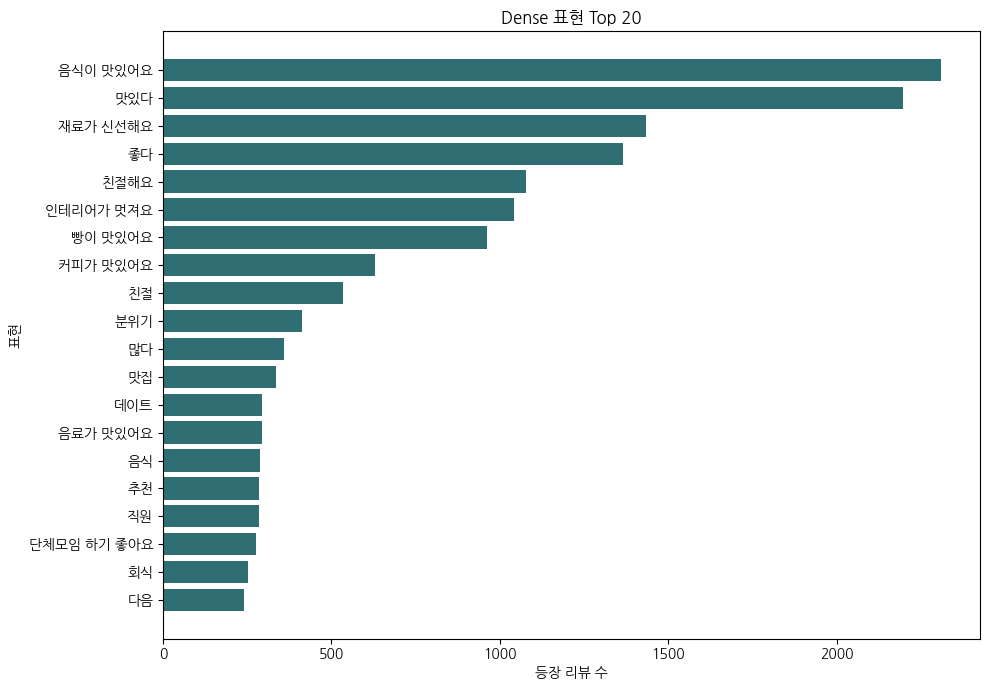

In [94]:
top_dense_plot_df = dense_df.head(20).sort_values("review_count")

plt.figure(figsize=(10, 7))
plt.barh(top_dense_plot_df["expression"], top_dense_plot_df["review_count"], color="#2f6f73")
plt.xlabel("등장 리뷰 수")
plt.ylabel("표현")
plt.title("Dense 표현 Top 20")
plt.tight_layout()
plt.show()

## 8. 표현 cluster network

노드는 표현이고, 선은 co-occurrence vector의 cosine similarity가 threshold 이상인 관계입니다. 가까운 맥락에서 함께 쓰인 표현들이 같은 덩어리로 묶입니다.

이 그림은 정답 cluster라기보다는 탐색 도구입니다. threshold를 올리면 더 엄격한 cluster가 되고, 낮추면 더 넓은 의미권이 연결됩니다.

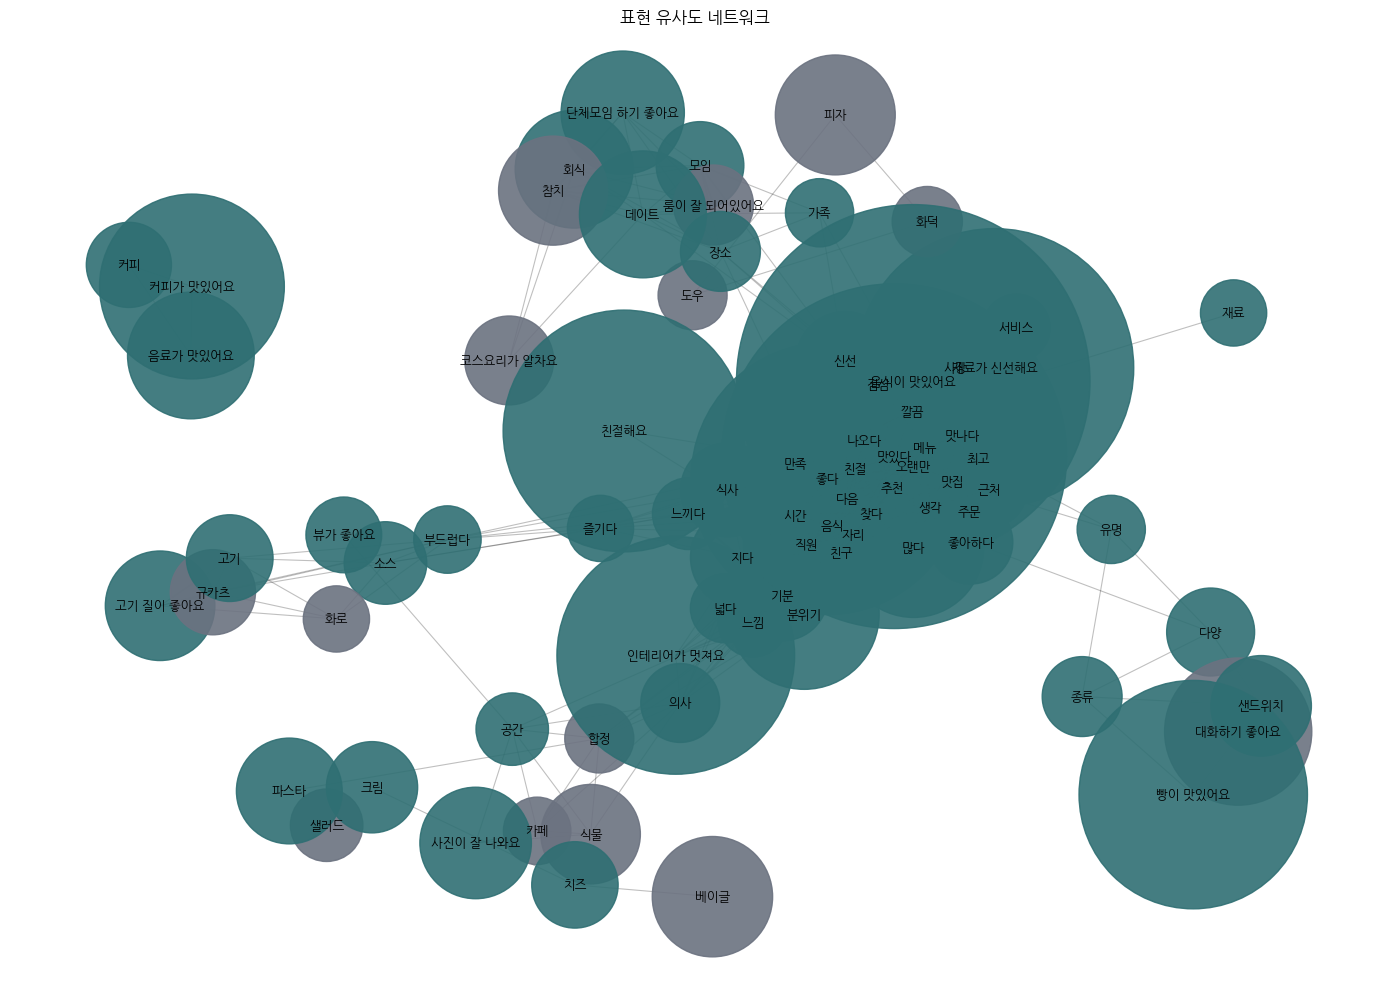

In [95]:
network_candidates = analysis_stats[analysis_stats["neighbor_count"] > 0].sort_values(
    ["review_count", "neighbor_count"], ascending=[False, False]
).head(MAX_NETWORK_NODES)["expression"].tolist()

network_graph = G.subgraph(network_candidates).copy()
color_by_label = {"dense": "#2f6f73", "sparse_meaningful": "#c77700", "sparse_noise": "#aaaaaa", "middle": "#6b7280"}
node_label_map = analysis_stats.set_index("expression")["density_label"].to_dict()
node_stat_map = analysis_stats.set_index("expression")["review_count"].to_dict()
node_colors = [color_by_label.get(node_label_map.get(node, "middle"), "#6b7280") for node in network_graph.nodes()]
node_sizes = [120 + 28 * int(node_stat_map.get(node, 1)) for node in network_graph.nodes()]

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(network_graph, seed=42, k=0.45)
nx.draw_networkx_edges(network_graph, pos, alpha=0.25, width=0.8)
nx.draw_networkx_nodes(network_graph, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(network_graph, pos, font_size=9, font_family=KOREAN_FONT_FAMILY)
plt.title("표현 유사도 네트워크")
plt.axis("off")
plt.tight_layout()
plt.show()

## 9. 2D SVD scatter

고차원 co-occurrence vector를 2차원으로 줄여 표현 공간을 봅니다. Word2Vec vector를 PCA나 t-SNE로 시각화하는 것과 비슷한 목적입니다.

가까이 찍힌 표현은 같은 리뷰 맥락, 같은 네이버 키워드, 같은 장소/카테고리와 함께 등장했을 가능성이 큽니다. 다만 2D 축소는 정보 손실이 있으므로, 최종 해석은 위의 표와 실제 리뷰 예시를 함께 확인해야 합니다.

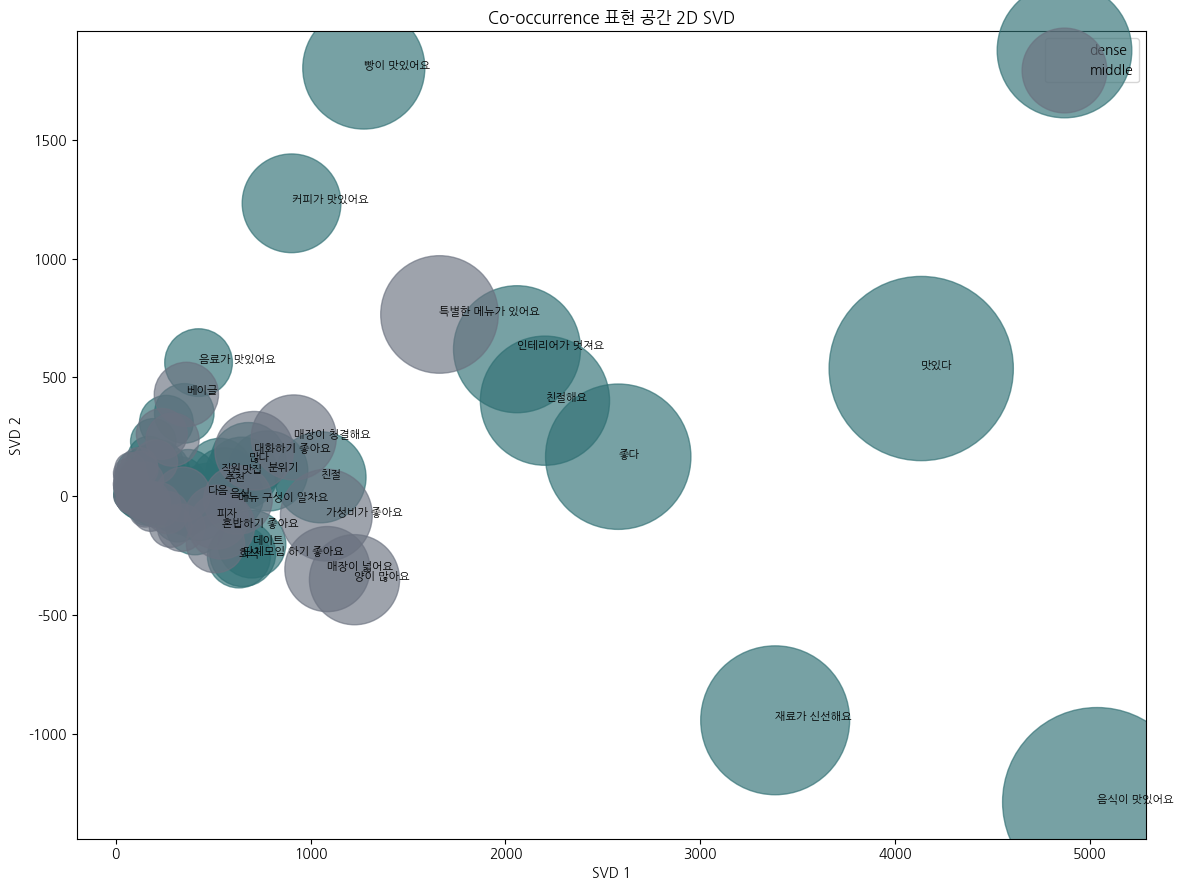

In [96]:
svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(context_matrix)
plot_df = pd.DataFrame({"expression": feature_expressions, "x": coords[:, 0], "y": coords[:, 1]})
plot_df = plot_df.merge(analysis_stats[["expression", "review_count", "density_label"]], on="expression", how="left")

plt.figure(figsize=(12, 9))
for density_label, group in plot_df.groupby("density_label"):
    plt.scatter(
        group["x"],
        group["y"],
        s=30 + group["review_count"] * 8,
        alpha=0.65,
        label=density_label,
        color=color_by_label.get(density_label, "#6b7280"),
    )

for row in plot_df.sort_values("review_count", ascending=False).head(30).itertuples(index=False):
    plt.text(row.x, row.y, row.expression, fontsize=8)

plt.title("Co-occurrence 표현 공간 2D SVD")
plt.xlabel("SVD 1")
plt.ylabel("SVD 2")
plt.legend()
plt.tight_layout()
plt.show()

## 10. 해석 가이드

이 노트북의 결과는 리뷰 텍스트를 해석하기 위한 출발점입니다. `dense` 표현은 전체 리뷰에서 공통적으로 반복되는 평가 언어를 보여 주고, `sparse_meaningful` 표현은 장소별 차이를 설명하는 후보가 됩니다.

주의할 점도 있습니다. 현재 데이터는 최신순 리뷰 500개뿐이므로, 계절성이나 최근 이벤트의 영향을 받을 수 있습니다. 또한 네이버 키워드는 사용자가 직접 선택한 structured signal이라 원문 텍스트보다 더 안정적이지만, 플랫폼이 제공한 선택지의 편향도 포함합니다.

최종 시각화에서는 표현 cluster를 그대로 정답처럼 쓰기보다, 실제 리뷰 예시와 함께 보여 주는 것이 좋습니다. Hidden Bites의 핵심 질문은 `리뷰 수가 많은 곳이 정말 좋은 곳인가?`이므로, 흔한 칭찬 표현뿐 아니라 특정 상황에서만 강하게 드러나는 표현을 같이 보여 주는 방향이 적합합니다.